### Use the cell below to download dataset 

In [44]:

# import os
# from dotenv import load_dotenv
# from huggingface_hub import snapshot_download

# load_dotenv()

# snapshot_download(
#     repo_id="DefectSpectrum/Defect_Spectrum",
#     repo_type="dataset",
#     token=os.getenv("HF_TOKEN"),
#     local_dir="./dataset",
#     allow_patterns=["DS-MVTec/metal_nut/image/*"],
#     max_workers=4,
# )

#  or
# download the MVTech dataset from  https://www.mvtec.com/research-teaching/datasets/mvtec-ad/downloads

In [45]:
import torch 
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import torch.nn.functional as F
from torchvision import transforms, models

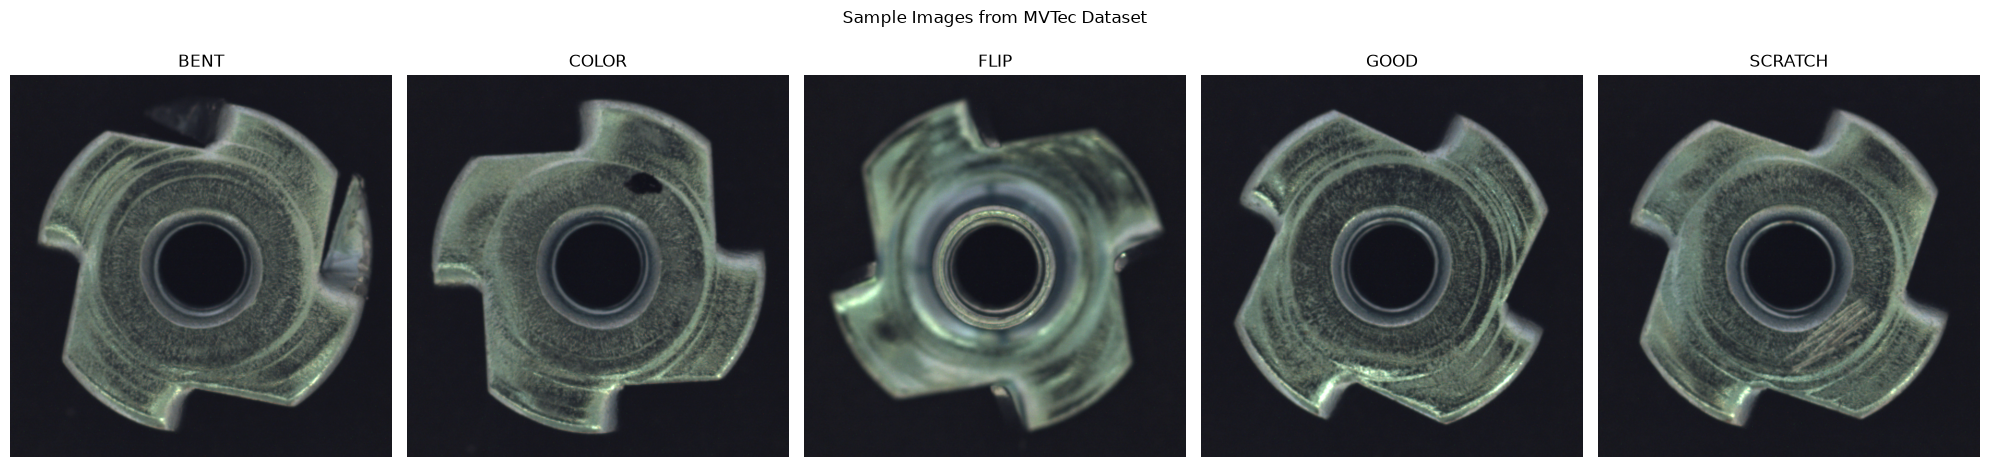

In [46]:
test_path = "dataset/metal_nut/test/"
classes = sorted(os.listdir(test_path))
fig, ax = plt.subplots(1, len(classes), figsize=(20, 5))
for i, cls in enumerate(classes):
    class_path = os.path.join(test_path, cls)
    # first image in the folder
    image_name = sorted(os.listdir(class_path))[0]
    img = cv2.imread(os.path.join(class_path, image_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax[i].imshow(img)
    ax[i].set_title(cls.upper())
    ax[i].axis("off")
fig.suptitle("Sample Images from MVTec Dataset")
plt.tight_layout()
plt.show()


In [47]:
# configure device and image parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 224  # input dim shape for mobilenet model
batch_size = 16

In [48]:
# apply image based operations

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225 ]) # normalize image in format suitable for RestNet weights
])

In [49]:
from PIL import Image
train_images = []
train_path = "dataset/metal_nut/train/"

for image_name in os.listdir(os.path.join(train_path, "good")):
    img = cv2.imread(os.path.join(train_path, "good/",image_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = transform(Image.fromarray(img))
    train_images.append(img)
    
print(f"Number of training images: {len(train_images)}")

Number of training images: 220


In [50]:
train_batched = []

for i in range(0, len(train_images), batch_size):
    batch = torch.stack(train_images[i:i+batch_size])
    train_batched.append(batch)

print(f"Number of training batches: {len(train_batched)}")
print(f"Shape of each batch: {train_batched[0].shape}")

Number of training batches: 14
Shape of each batch: torch.Size([16, 3, 224, 224])


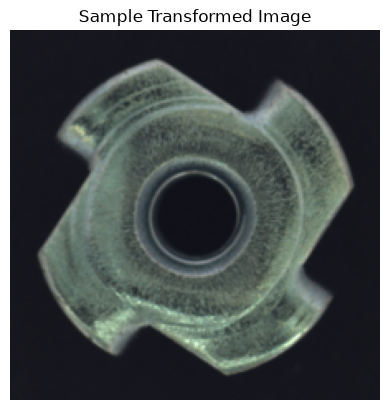

In [51]:
# visualize a sample with transformation 

image = train_images[0].permute(1, 2, 0).numpy()  # from (C, H, W) to (H, W, C)
# unnormalize the image
image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image = np.clip(image, 0, 1)  # clip values to [0, 1] range

plt.imshow(image)
plt.title("Sample Transformed Image")
plt.axis("off")
plt.show()

In [52]:
# load resnet18 model pretrained on ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model = model.to(device)
model.eval()  # set model to evaluation mode

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [53]:
features = []

def hook_fn(module, input, output):
    features.append(output.detach())

model.layer1.register_forward_hook(hook_fn)
model.layer2.register_forward_hook(hook_fn)
model.layer3.register_forward_hook(hook_fn)


In [54]:
# verify shape of feature
features.clear()

batch = train_batched[0].to(device)
with torch.no_grad():
    _ = model(batch)

for i, feature in enumerate(features):
    print(f"Feature map from layer {i+1}: shape = {feature.shape}")

Feature map from layer 1: shape = torch.Size([16, 64, 56, 56])
Feature map from layer 2: shape = torch.Size([16, 128, 28, 28])
Feature map from layer 3: shape = torch.Size([16, 256, 14, 14])


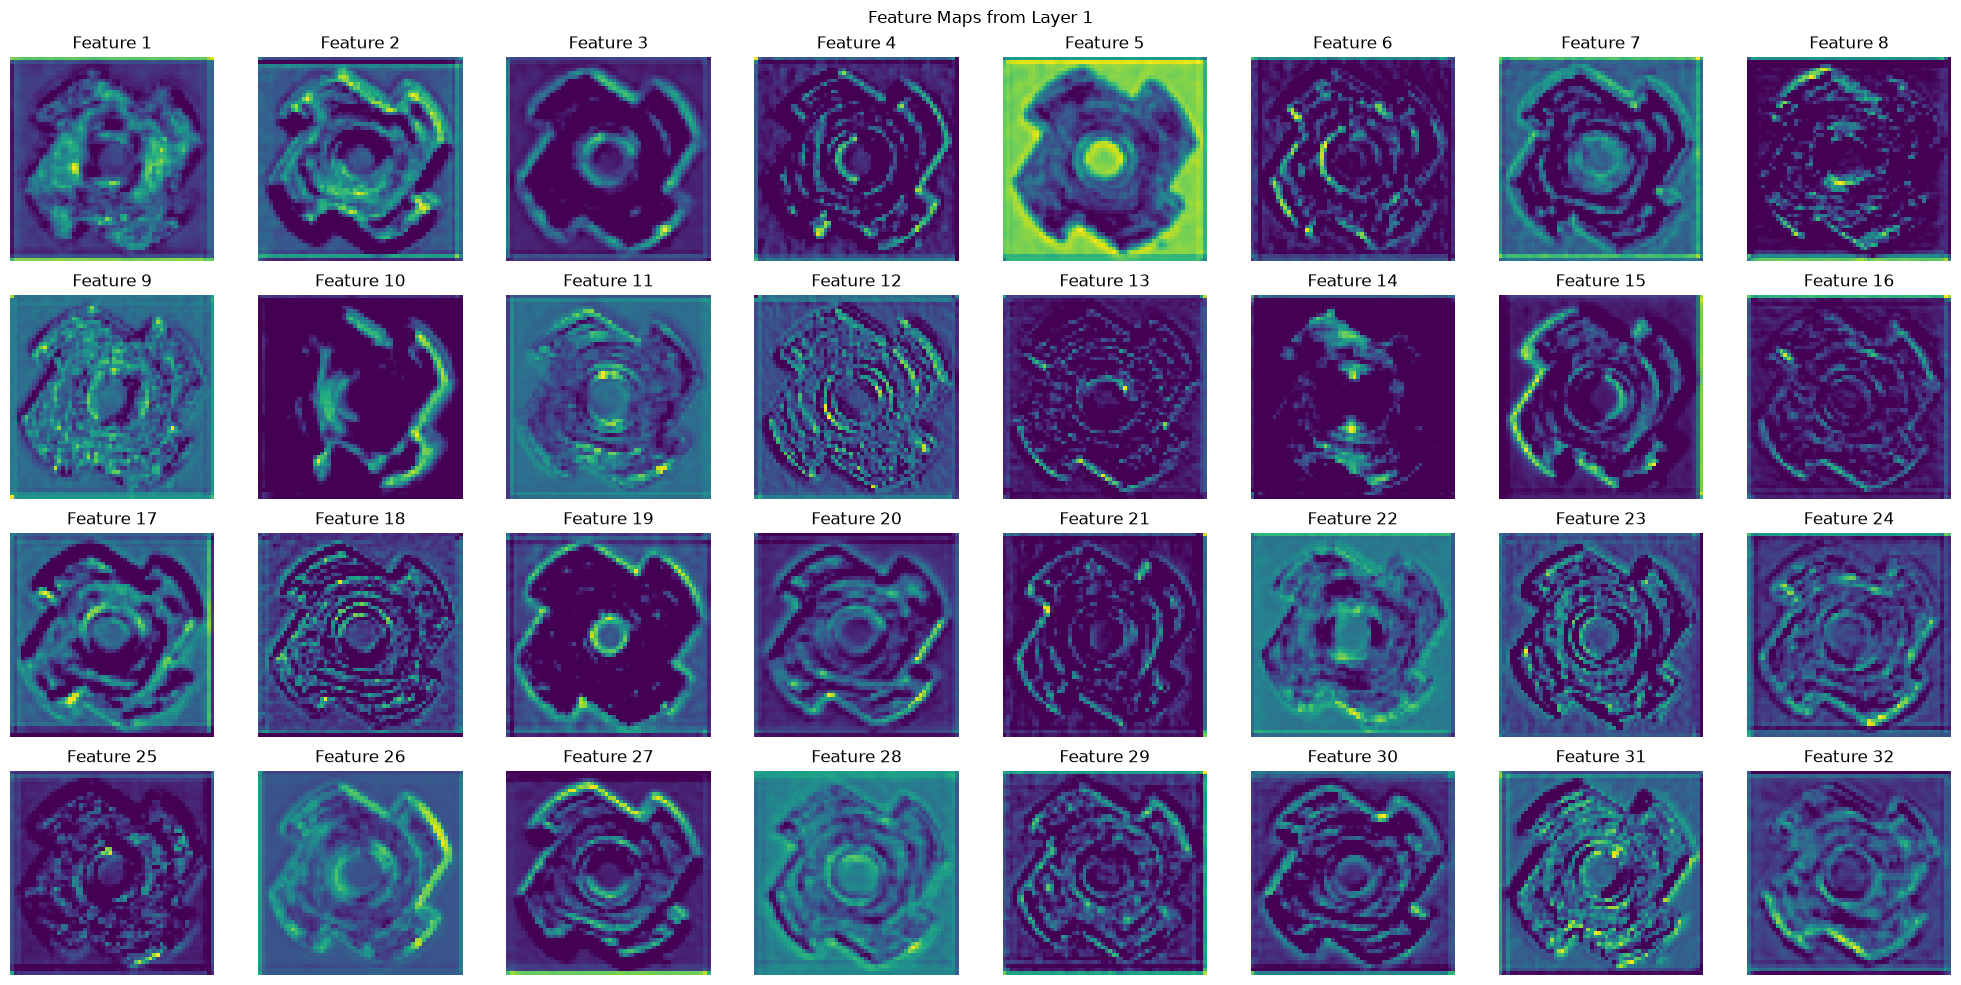

In [55]:
# visualize feature maps from the first layer
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 8, figsize=(20, 10))
for i in range(32):  # visualize first 32 feature maps
    row = i // 8
    col = i % 8
    ax[row, col].imshow(features[0][0, i].cpu(), cmap='viridis')
    ax[row, col].axis('off')
    ax[row, col].set_title(f'Feature {i+1}')
fig.suptitle("Feature Maps from Layer 1")
plt.tight_layout()
plt.show()

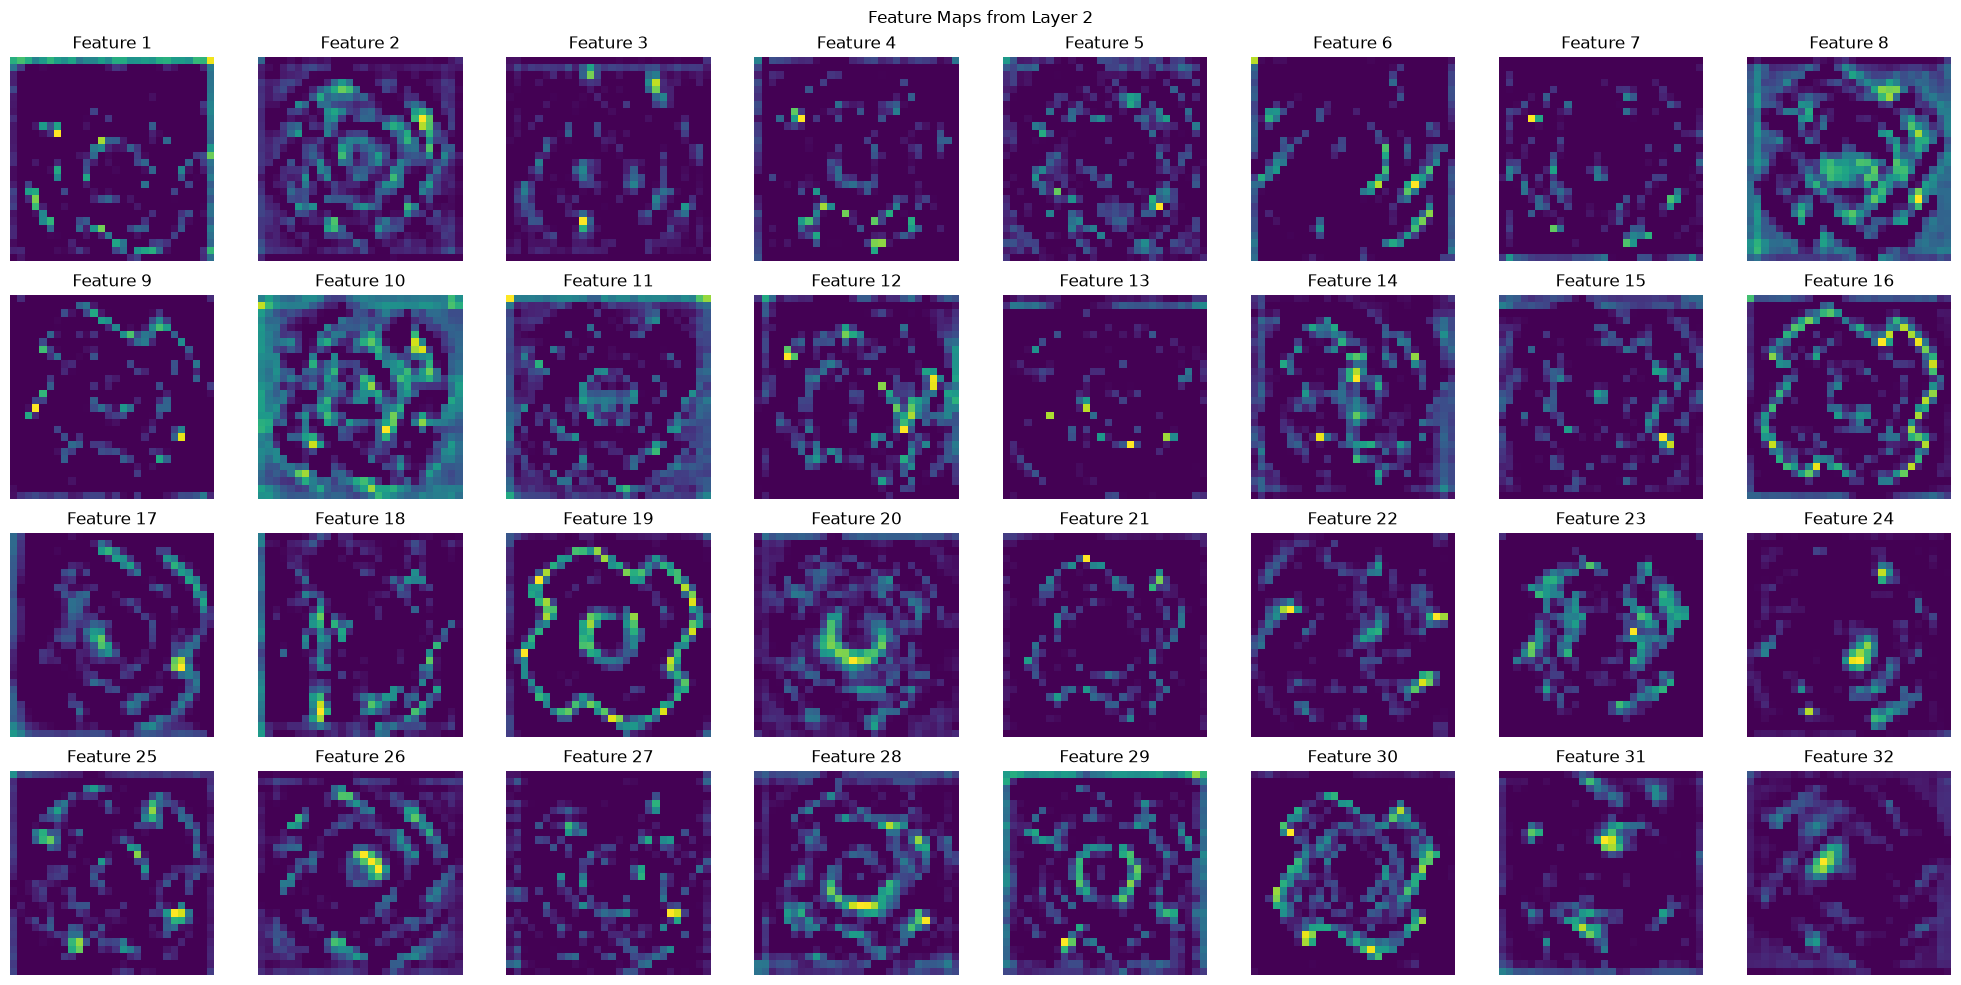

In [56]:
# feature map for layer 2
fig, ax = plt.subplots(4, 8, figsize=(20, 10))
for i in range(32):  # visualize first 32 feature maps
    row = i // 8
    col = i % 8
    ax[row, col].imshow(features[1][0, i].cpu(), cmap='viridis')
    ax[row, col].axis('off')
    ax[row, col].set_title(f'Feature {i+1}')

fig.suptitle("Feature Maps from Layer 2")
plt.tight_layout()
plt.show()

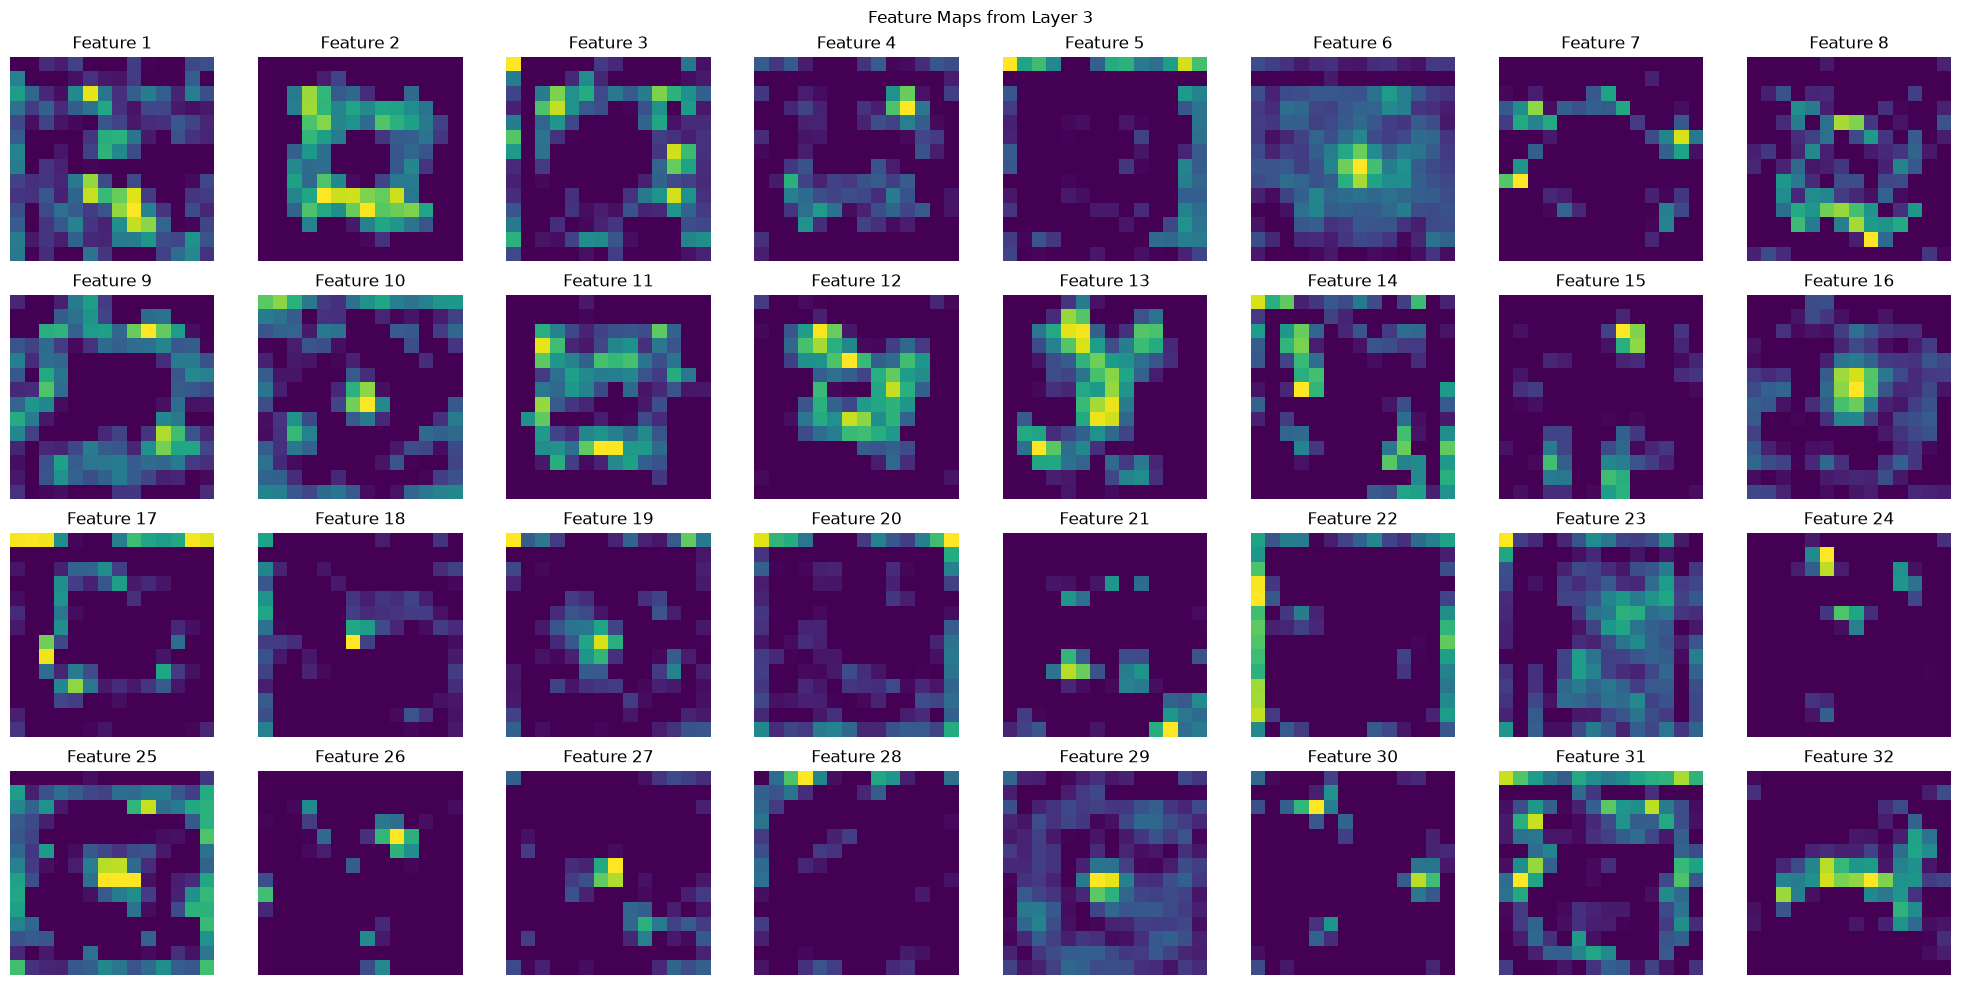

In [57]:
# feature map for layer 3
fig, ax = plt.subplots(4, 8, figsize=(20, 10))
for i in range(32):  # visualize first 32 feature maps
    row = i // 8
    col = i % 8
    ax[row, col].imshow(features[2][0, i].cpu(), cmap='viridis')
    ax[row, col].axis('off')
    ax[row, col].set_title(f'Feature {i+1}')

fig.suptitle("Feature Maps from Layer 3")
plt.tight_layout()
plt.show()

In [58]:
# upsampling features as PaDiM require all sample to be in same spatial space

layer1 = features[0]
layer2 = F.interpolate(features[1], size=layer1.shape[-2:], mode='bilinear', align_corners=False)
layer3 = F.interpolate(features[2], size=layer1.shape[-2:], mode='bilinear', align_corners=False)

print(f"Layer 1 shape: {layer1.shape}")
print(f"Layer 2 shape after upsampling: {layer2.shape}")
print(f"Layer 3 shape after upsampling: {layer3.shape}")

Layer 1 shape: torch.Size([16, 64, 56, 56])
Layer 2 shape after upsampling: torch.Size([16, 128, 56, 56])
Layer 3 shape after upsampling: torch.Size([16, 256, 56, 56])


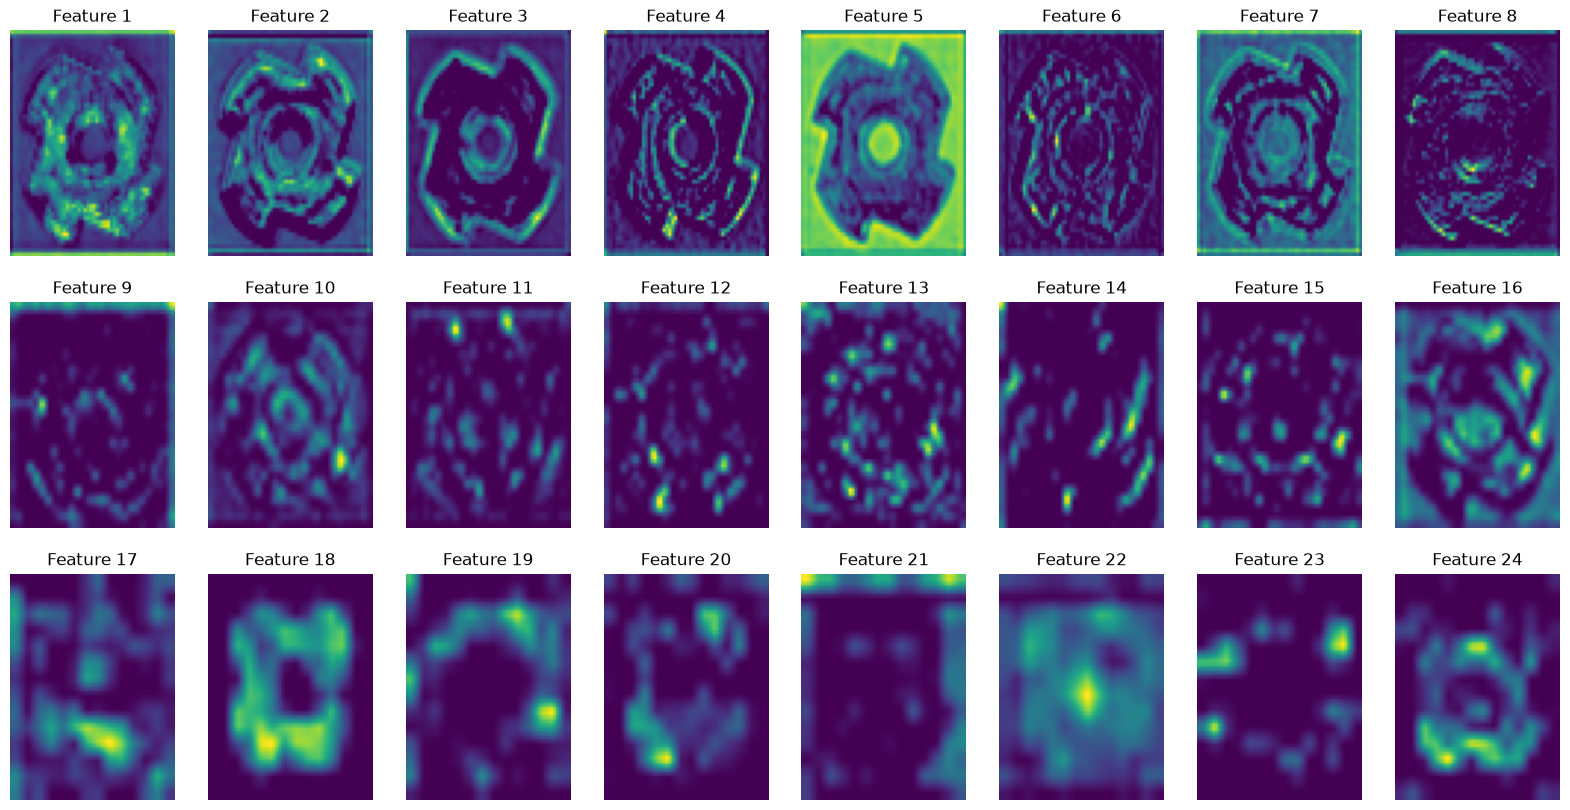

In [97]:
# post interpolation embedding view

fig, ax = plt.subplots(3, 8, figsize=(20, 10))

for i in range(24):  # visualize first 8 of each feature map
    row = i // 8
    col = i % 8
    if i < 8:
        ax[row, col].imshow(layer1[0, i].cpu(), cmap='viridis', aspect='auto')
    elif i < 16:
        ax[row, col].imshow(layer2[0, i-8].cpu(), cmap='viridis', aspect='auto')
    else:
        ax[row, col].imshow(layer3[0, i - 16].cpu(), cmap='viridis', aspect='auto')
    ax[row, col].axis('off')
    ax[row, col].set_title(f'Feature {i+1}')

In [59]:
# join all features along channel dimension
embedding = torch.cat([layer1, layer2, layer3], dim=1)

print(f"Combined embedding shape: {embedding.shape}")

Combined embedding shape: torch.Size([16, 448, 56, 56])


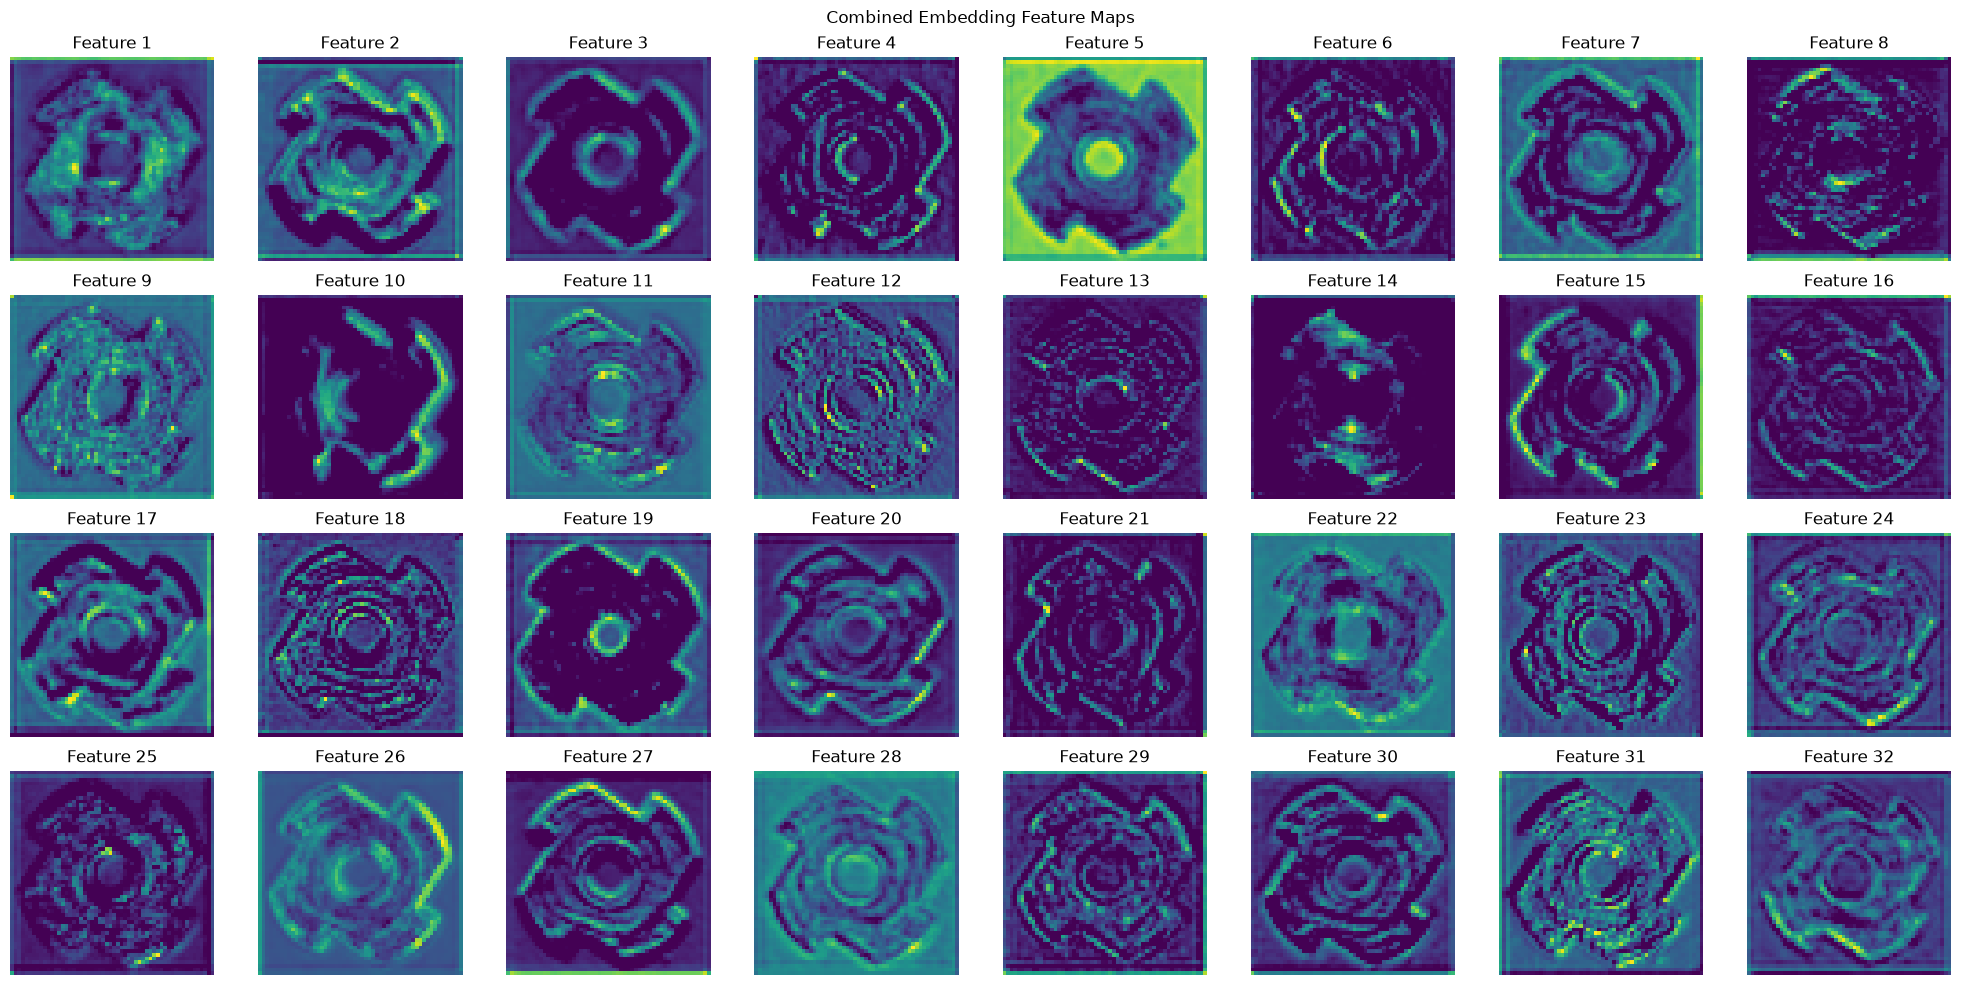

In [ ]:
# visualize the combined embedding
fig, ax = plt.subplots(4, 8, figsize=(20, 10))
for i in range(32):  # visualize first 32 feature maps
    row = i // 8
    col = i % 8
    ax[row, col].imshow(embedding[0, i], cmap='viridis')
    ax[row, col].axis('off')
    ax[row, col].set_title(f'Feature {i+1}')
    
fig.suptitle("Combined Embedding Feature Maps")
plt.tight_layout()
plt.show()

### Now do the above steps on a whole for all images in the training batch

In [ ]:
# random channel selection process
torch.manual_seed(42)  # for reproducibility
selected_channels = torch.randperm(embedding.shape[1])[:64]  # select 64 random channels
embedding = embedding[:, selected_channels, :, :]

print(f"Embedding shape after channel selection: {embedding.shape}")


Embedding shape after channel selection: torch.Size([16, 64, 56, 56])


In [ ]:
all_embeddings = []

with torch.no_grad():
    for batch in train_batched:
        features.clear()  # clear previous features
        batch = batch.to(device) 
        _ = model(batch) # hook function stores the features in the global list
        # upsample features
        layer1 = features[0]
        layer2 = F.interpolate(features[1], size=layer1.shape[-2:], mode='bilinear', align_corners=False)
        layer3 = F.interpolate(features[2], size=layer1.shape[-2:], mode='bilinear', align_corners=False)
        # join all features along channel dimension
        embedding = torch.cat([layer1, layer2, layer3], dim=1) # combined embedding after interpolation
        # random channel selection process
        embedding = embedding[:, selected_channels, :, :] # selected channel from global random selection
        all_embeddings.append(embedding.cpu())

In [67]:
all_embeddings = torch.cat(all_embeddings, dim=0)
print(f"All embeddings shape: {all_embeddings.shape}")

All embeddings shape: torch.Size([220, 64, 56, 56])


In [68]:
# convert pytorch tensor to numpy array for further processing
embeddings = all_embeddings.numpy()
print(f"Embeddings numpy array shape: {embeddings.shape}")

Embeddings numpy array shape: (220, 64, 56, 56)


In [69]:
# rearrange as np and pytorch has diff dim usage

embeddings = np.transpose(embeddings, (0, 2, 3, 1))  # from (N, C, H, W) to (N, H, W, C)

print(f"Embeddings shape after transpose: {embeddings.shape}")

Embeddings shape after transpose: (220, 56, 56, 64)


In [70]:
mean = np.mean(embeddings, axis=0)
print(f"Mean embedding shape: {mean.shape}")

Mean embedding shape: (56, 56, 64)


In [ ]:
# spacial covar matrix (local covariance matrix for each pixel location across all channels)
H, W, C = mean.shape

covar = np.zeros((H, W, C, C), dtype=np.float32)

identity = np.eye(C, dtype=np.float32) * 0.01

for i in range(H):
    for j in range(W):

        feature_vectors = embeddings[:, i, j, :]

        covar[i, j] = np.cov(
            feature_vectors,
            rowvar=False
        ) + identity

In [72]:
print(f"Covariance matrix shape: {covar.shape}")

Covariance matrix shape: (56, 56, 64, 64)


### Training Pipeline is over. We have the probability vectors as embeddings 

In [73]:
test_image_path = 'dataset/metal_nut/test/good/005.png'

img_test = Image.open(test_image_path).convert('RGB')

original_image = np.array(img_test)

input_image = transform(img_test).unsqueeze(0).to(device)

print(f"Input image shape: {input_image.shape}")
 

Input image shape: torch.Size([1, 3, 224, 224])


In [74]:
features.clear()

with torch.no_grad():
    _ = model(input_image)

layer1 = features[0]
layer2 = F.interpolate(features[1],size=layer1.shape[-2:],mode="bilinear",align_corners=False)
layer3 = F.interpolate(features[2],size=layer1.shape[-2:],mode="bilinear",align_corners=False)

In [75]:
embedding = torch.cat([layer1, layer2, layer3],dim=1)

embedding = embedding[:, selected_channels, :, :]

print(embedding.shape)

torch.Size([1, 64, 56, 56])


In [76]:
embedding = embedding.squeeze(0).cpu().numpy()
print(f"Embedding shape after squeeze: {embedding.shape}")
embedding = np.transpose(embedding, (1, 2, 0))  # from (C, H, W) to (H, W, C)
print(f"Embedding shape after squeeze and transpose: {embedding.shape}")

Embedding shape after squeeze: (64, 56, 56)
Embedding shape after squeeze and transpose: (56, 56, 64)


In [77]:
H, W, C = mean.shape

cov_inv = np.zeros_like(covar)

for i in range(H):
    for j in range(W):
        cov_inv[i, j] = np.linalg.inv(covar[i, j])

print(cov_inv.shape)

(56, 56, 64, 64)


In [78]:
anomaly_map = np.zeros((H, W), dtype=np.float32)

for i in range(H):
    for j in range(W):
        x = embedding[i, j]
        diff = x - mean[i, j]
        anomaly_map[i, j] = np.sqrt(diff @ cov_inv[i, j] @ diff.T)
print(anomaly_map.shape)

(56, 56)


In [79]:
print(anomaly_map.min())
print(anomaly_map.max())
print(anomaly_map.mean())

1.4725926
9.898701
4.359914


In [80]:
H_orig, W_orig = original_image.shape[:2]

anomaly_map = torch.tensor(anomaly_map)
anomaly_map = anomaly_map.unsqueeze(0).unsqueeze(0)
anomaly_map = F.interpolate(anomaly_map, size=(H_orig, W_orig), mode="bilinear", align_corners=False)
anomaly_map = anomaly_map.squeeze().numpy()

In [81]:
from scipy.ndimage import gaussian_filter
anomaly_map = gaussian_filter(anomaly_map,sigma=4)

(np.float64(-0.5), np.float64(699.5), np.float64(699.5), np.float64(-0.5))

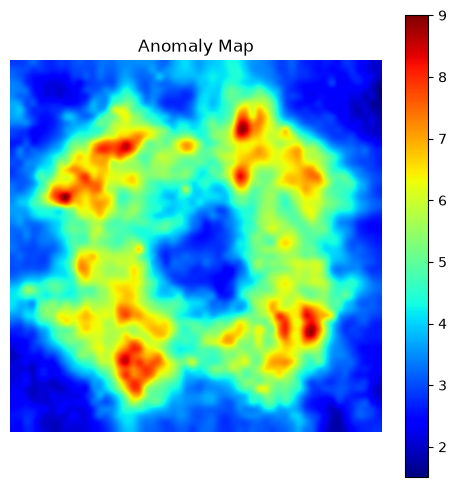

In [82]:
plt.figure(figsize=(6,6))
plt.imshow(anomaly_map, cmap="jet")
plt.colorbar()
plt.title("Anomaly Map")
plt.axis("off")

Text(0.5, 1.0, 'Overlay')

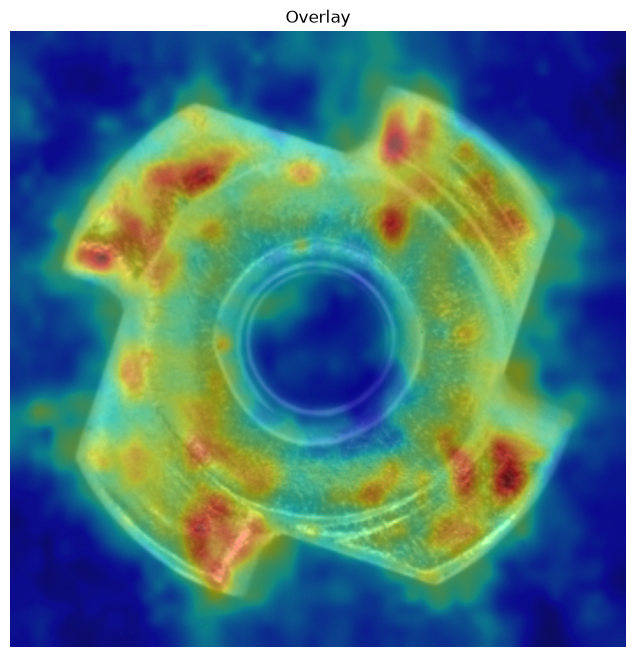

In [83]:
plt.figure(figsize=(8,8))
plt.imshow(original_image)
plt.imshow(
    anomaly_map,
    cmap="jet",
    alpha=0.5
)
plt.axis("off")
plt.title("Overlay")

In [84]:
score = anomaly_map.max()

print(score)

9.003941


In [85]:
print(anomaly_map.min())
print(anomaly_map.max())
print(anomaly_map.mean())

1.5105165
9.003941
4.359914


In [86]:
def compute_anomaly_map(image_path, target_size=None):
    img = Image.open(image_path).convert('RGB')
    original = np.array(img)
    input_image = transform(img).unsqueeze(0).to(device)

    features.clear()
    with torch.no_grad():
        _ = model(input_image)

    l1 = features[0]
    l2 = F.interpolate(features[1], size=l1.shape[-2:], mode='bilinear', align_corners=False)
    l3 = F.interpolate(features[2], size=l1.shape[-2:], mode='bilinear', align_corners=False)

    emb = torch.cat([l1, l2, l3], dim=1)
    emb = emb[:, selected_channels, :, :]
    emb = emb.squeeze(0).cpu().numpy()
    emb = np.transpose(emb, (1, 2, 0))  # H, W, C

    H, W, C = emb.shape
    amap = np.zeros((H, W), dtype=np.float32)
    for i in range(H):
        for j in range(W):
            diff = emb[i, j] - mean[i, j]
            amap[i, j] = np.sqrt(diff @ cov_inv[i, j] @ diff.T)

    out_size = target_size if target_size else original.shape[:2]
    amap_t = torch.tensor(amap).unsqueeze(0).unsqueeze(0)
    amap_t = F.interpolate(amap_t, size=out_size, mode='bilinear', align_corners=False)
    amap = amap_t.squeeze().numpy()
    amap = gaussian_filter(amap, sigma=4)
    return amap, original

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

test_root = "dataset/metal_nut/test/"
gt_root = "dataset/metal_nut/ground_truth/"

image_scores, image_labels = [], []
pixel_scores_all, pixel_labels_all = [], []

for cls in sorted(os.listdir(test_root)):
    cls_path = os.path.join(test_root, cls)
    for fname in sorted(os.listdir(cls_path)):
        amap, _ = compute_anomaly_map(os.path.join(cls_path, fname))

        image_scores.append(amap.max())
        image_labels.append(0 if cls == "good" else 1)

        if cls != "good":
            gt_path = os.path.join(gt_root, cls, fname.replace(".png", "_mask.png"))
            if os.path.exists(gt_path):
                gt = np.array(Image.open(gt_path).convert('L'))
                gt = (gt > 0).astype(np.uint8)
                pixel_scores_all.append(amap.flatten())
                pixel_labels_all.append(gt.flatten())

image_auroc = roc_auc_score(image_labels, image_scores)
print(f"Image-level AUROC: {image_auroc:.4f}")

pixel_scores_all = np.concatenate(pixel_scores_all)
pixel_labels_all = np.concatenate(pixel_labels_all)
pixel_auroc = roc_auc_score(pixel_labels_all, pixel_scores_all)
print(f"Pixel-level AUROC: {pixel_auroc:.4f}")

Image-level AUROC: 0.9536
Pixel-level AUROC: 0.9473


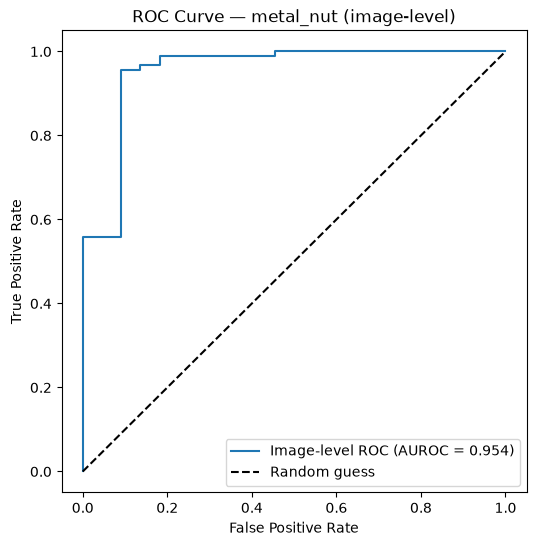

In [88]:
fpr, tpr, _ = roc_curve(image_labels, image_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Image-level ROC (AUROC = {image_auroc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — metal_nut (image-level)")
plt.legend()
plt.show()

In [102]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(image_labels, image_scores)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Chosen threshold: {best_threshold:.4f}")
print(f"At this threshold -> TPR: {tpr[best_idx]:.3f}, FPR: {fpr[best_idx]:.3f}")

Chosen threshold: 10.5255
At this threshold -> TPR: 0.957, FPR: 0.091


In [103]:
image_preds = [1 if score >= best_threshold else 0 for score in image_scores]

In [104]:
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(image_labels,image_preds,target_names=["good", "defective"],digits=4)
print(report)
cm = confusion_matrix(image_labels, image_preds)
print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

        good     0.8333    0.9091    0.8696        22
   defective     0.9780    0.9570    0.9674        93

    accuracy                         0.9478       115
   macro avg     0.9057    0.9330    0.9185       115
weighted avg     0.9503    0.9478    0.9487       115

Confusion Matrix:
[[20  2]
 [ 4 89]]


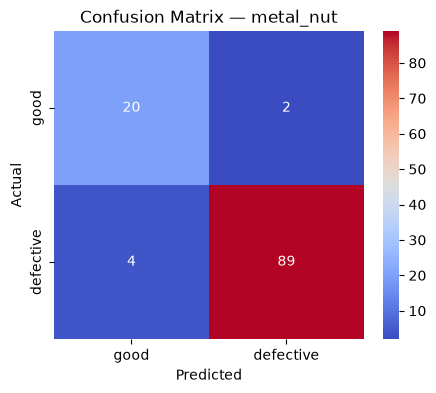

In [108]:
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",xticklabels=["good", "defective"], yticklabels=["good", "defective"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — metal_nut")
plt.show()